# Regime Monitor Validation — Phase 1

Validates `get_regime_series()` against historical SPY drawdowns per `master_plan_v4.md` Phase 1 pass criteria.

**Pass criteria:**
- GFC: RED triggers >= 5 trading days before SPY crosses -10% in the 2008-06-01 to 2009-12-31 window
- COVID: RED triggers at some point in the 2020-02-01 to 2020-06-30 window
- 2022 H1: YELLOW or RED triggers at some point in 2022-01-01 to 2022-06-30

In [1]:
import sys
from pathlib import Path
from datetime import date

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import yfinance as yf
from dotenv import load_dotenv

sys.path.insert(0, str(Path('..').resolve()))
load_dotenv(Path('../.env'))

from src.regime.fred_client import FREDClient
from src.regime.monitor import get_regime_series

Path('figures').mkdir(exist_ok=True)
print('Setup complete')

Setup complete


In [2]:
START = date(2007, 1, 1)
END   = date(2024, 12, 31)

_fetch_start = (pd.Timestamp(START) - pd.offsets.BDay(10)).date()
_client      = FREDClient.from_settings()

raw_spreads = _client.fetch_composite_spread(start=_fetch_start, end=END)

print(f"Raw FRED composite: {len(raw_spreads):,} observations")
print(f"  date range : {raw_spreads.index[0].date()} → {raw_spreads.index[-1].date()}")
print(f"  min / max  : {raw_spreads.min():.2f} / {raw_spreads.max():.2f}")
n_red = int((raw_spreads > 3.50).sum())
print(f"  values > 3.50 (RED threshold): {n_red:,}  ← must be > 0 for GFC/COVID to appear")
if n_red == 0:
    raise RuntimeError(
        "FRED returned no RED-range values — check FRED_API_KEY "
        "and that historical data is being fetched."
    )

print()
print("Computing regime series...")
regimes = get_regime_series(start=START, end=END, client=_client)
regimes = regimes.ffill()

print()
print("Regime value_counts (dropna=False — NaN means alignment gap):")
print(regimes.value_counts(dropna=False).to_string())
print(f"NaN count : {regimes.isna().sum()}")

print()
print("Spot-checks — expect RED during GFC and COVID:")
for dt_str, note in [
    ('2008-10-13', 'GFC near peak'),
    ('2009-01-20', 'GFC trough period'),
    ('2020-03-23', 'COVID low'),
]:
    val = regimes.get(pd.Timestamp(dt_str), 'N/A')
    flag = '✓' if val == 'RED' else f'✗  UNEXPECTED ({val})'
    print(f"  {dt_str}  {note:<22}  {flag}")

Raw FRED composite: 4,509 observations
  date range : 2006-12-18 → 2024-12-31
  min / max  : 1.36 / 6.16
  values > 3.50 (RED threshold): 249  ← must be > 0 for GFC/COVID to appear

Computing regime series...

Regime value_counts (dropna=False — NaN means alignment gap):
BAA_spread
GREEN     2491
YELLOW    1944
RED        261
NaN          1
NaN count : 1

Spot-checks — expect RED during GFC and COVID:
  2008-10-13  GFC near peak           ✓
  2009-01-20  GFC trough period       ✓
  2020-03-23  COVID low               ✓


In [3]:
print('Fetching SPY daily closes from yfinance...')
spy_raw = yf.download(
    'SPY',
    start='2007-01-01',
    end='2025-01-01',
    auto_adjust=True,
    progress=False,
)
close_col = spy_raw['Close']
spy = close_col.iloc[:, 0] if isinstance(close_col, pd.DataFrame) else close_col
spy = spy.squeeze().rename('SPY')

# yfinance >= 0.2 returns a tz-aware (UTC) index; bdate_range is tz-naive.
# Mismatched tz causes reindex to silently produce all-NaN, making SPY a flat line.
spy.index = pd.to_datetime(spy.index)
if spy.index.tz is not None:
    spy.index = spy.index.tz_convert(None)
spy = spy[spy.index <= pd.Timestamp('2024-12-31')]

spy = spy.reindex(regimes.index).ffill()
drawdown = (spy / spy.cummax() - 1) * 100

print(f'SPY: {len(spy):,} days aligned')
print(f'Worst drawdown in period: {drawdown.min():.1f}%  (expect ~ -56% for GFC)')

Fetching SPY daily closes from yfinance...


SPY: 4,697 days aligned
Worst drawdown in period: -55.2%  (expect ~ -56% for GFC)


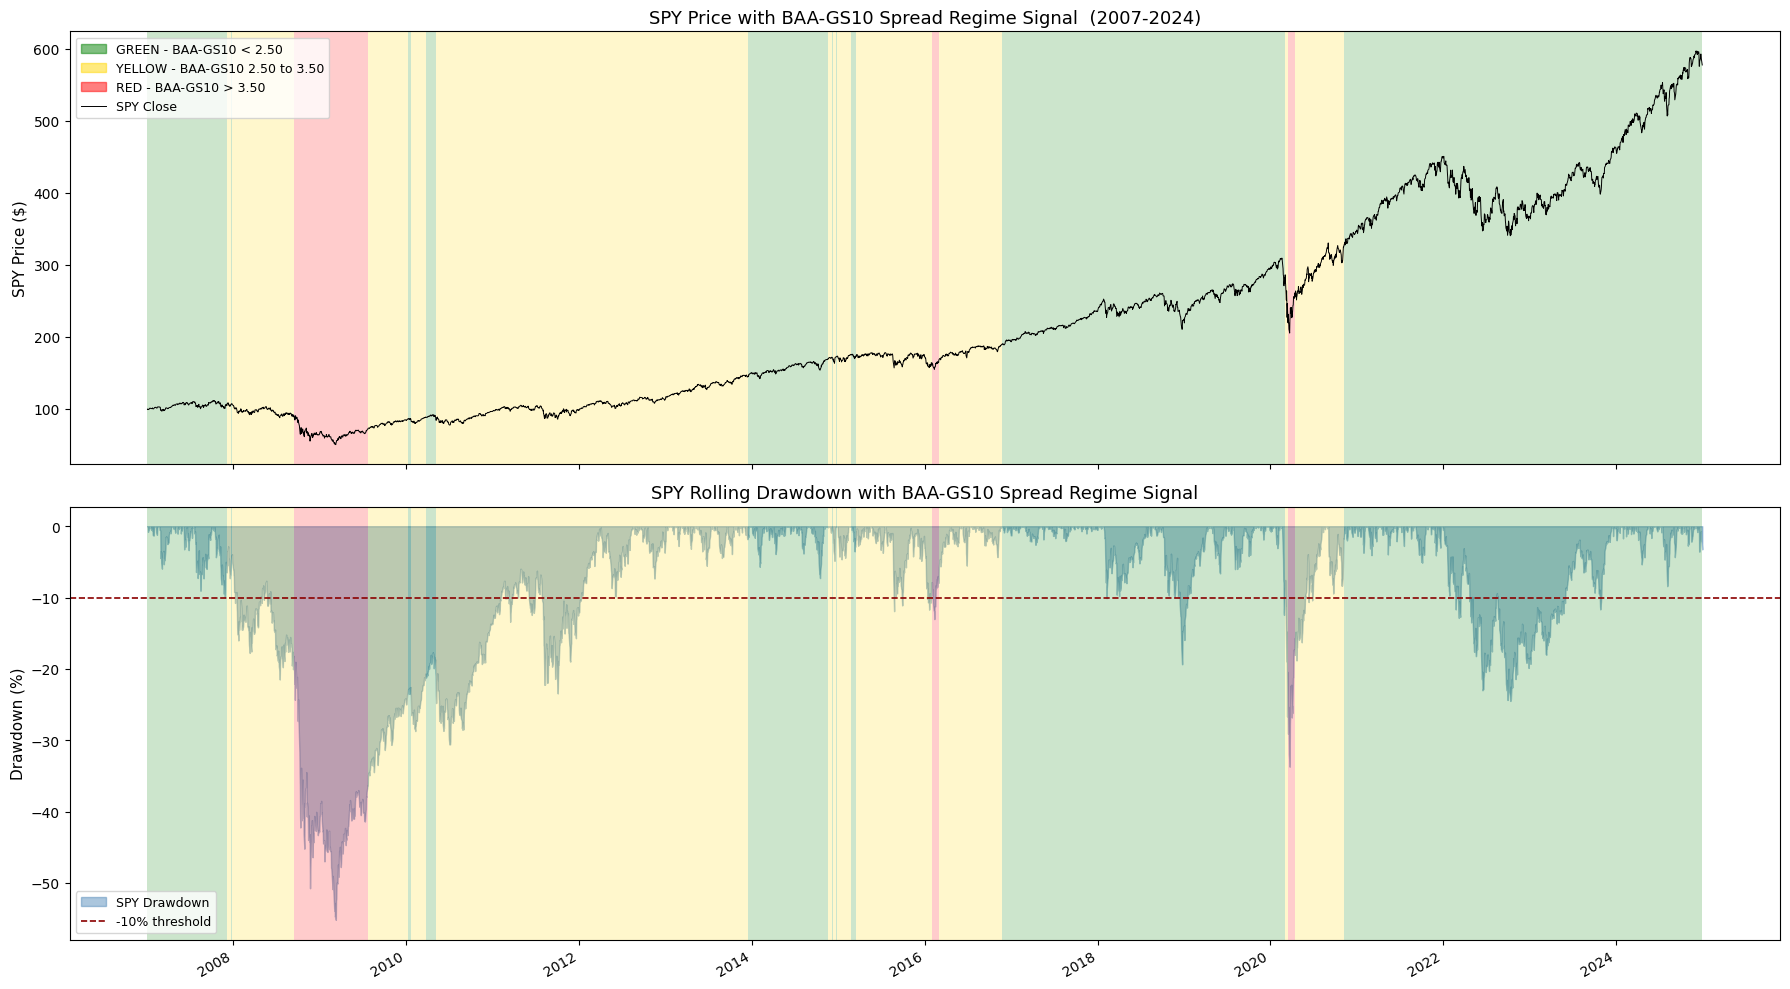

Figure saved to figures/regime_validation.png


In [4]:
REGIME_COLORS = {'GREEN': 'green', 'YELLOW': 'gold', 'RED': 'red'}


def shade_regimes(ax, regime_series):
    current = None
    block_start = None
    for dt, val in regime_series.items():
        if pd.isna(val):
            continue
        if val != current:
            if current is not None:
                ax.axvspan(block_start, dt, alpha=0.2,
                           color=REGIME_COLORS[current], lw=0)
            current = val
            block_start = dt
    if current is not None:
        ax.axvspan(block_start, regime_series.index[-1], alpha=0.2,
                   color=REGIME_COLORS[current], lw=0)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

ax1.plot(spy.index, spy.values, color='black', linewidth=0.7, label='SPY Close')
shade_regimes(ax1, regimes)
ax1.set_ylabel('SPY Price ($)', fontsize=11)
ax1.set_title('SPY Price with BAA-GS10 Spread Regime Signal  (2007-2024)', fontsize=13)
ax1.legend(
    handles=[
        mpatches.Patch(color='green', alpha=0.5, label='GREEN - BAA-GS10 < 2.50'),
        mpatches.Patch(color='gold',  alpha=0.5, label='YELLOW - BAA-GS10 2.50 to 3.50'),
        mpatches.Patch(color='red',   alpha=0.5, label='RED - BAA-GS10 > 3.50'),
        plt.Line2D([0], [0], color='black', linewidth=0.7, label='SPY Close'),
    ],
    loc='upper left', fontsize=9,
)

ax2.fill_between(drawdown.index, drawdown.values, 0,
                 color='steelblue', alpha=0.45, label='SPY Drawdown')
ax2.axhline(-10, color='darkred', linestyle='--', linewidth=1.2,
            label='-10% threshold')
shade_regimes(ax2, regimes)
ax2.set_ylabel('Drawdown (%)', fontsize=11)
ax2.set_title('SPY Rolling Drawdown with BAA-GS10 Spread Regime Signal', fontsize=13)
ax2.legend(loc='lower left', fontsize=9)

fig.autofmt_xdate()
fig.tight_layout()
fig.savefig('figures/regime_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to figures/regime_validation.png')

### Event window methodology

Event windows are scoped to the specific crisis being measured. The 2007-2008 period contained a brief unrelated -10% dip in January 2008 that recovered before the real crisis began, so the GFC window starts 2008-06-01.

COVID was a 4-week exogenous shock, not a credit-cycle event. Credit spreads (including ICE BofA HY OAS) lagged SPY in March 2020. The regime monitor is required to flag RED during the crash window, not lead it.

In [5]:
# Normalize regime series for safe .isin() / equality checks.
# The Series.name being set ('BAA_spread') can interfere with .isin() in some
# pandas versions, silently returning False even when YELLOW/RED are present.
regimes_clean = regimes.copy()
regimes_clean.name = None
regimes_clean = regimes_clean.astype(str)

# Diagnostic — confirm what regime values are actually present in the 2022 H1 window
_h22_diag = regimes_clean[
    (regimes_clean.index >= pd.Timestamp('2022-01-01')) &
    (regimes_clean.index <= pd.Timestamp('2022-06-30'))
]
print(f"2022 H1 unique regime values: {sorted(_h22_diag.unique())}")
print('2022 H1 value_counts:')
print(_h22_diag.value_counts().to_string())
print()

events = [
    dict(name='2008-09 GFC',
         scan_start=pd.Timestamp('2008-06-01'),
         scan_end=pd.Timestamp('2009-12-31'),
         criterion='LEAD_RED'),
    dict(name='2020-02/03 COVID',
         scan_start=pd.Timestamp('2020-02-01'),
         scan_end=pd.Timestamp('2020-06-30'),
         criterion='ANY_RED'),
    dict(name='2022 H1 Fed tightening',
         scan_start=pd.Timestamp('2022-01-01'),
         scan_end=pd.Timestamp('2022-06-30'),
         criterion='ANY_YELLOW_OR_RED'),
]

rows = []
for ev in events:
    w_reg = regimes_clean[(regimes_clean.index >= ev['scan_start']) &
                          (regimes_clean.index <= ev['scan_end'])]
    w_dd  = drawdown[(drawdown.index >= ev['scan_start']) &
                     (drawdown.index <= ev['scan_end'])]

    if ev['criterion'] == 'ANY_YELLOW_OR_RED':
        trigger_mask = w_reg.isin(['YELLOW', 'RED'])
    else:
        trigger_mask = w_reg == 'RED'

    trigger_dates  = w_reg.index[trigger_mask]
    regime_trigger = trigger_dates[0] if len(trigger_dates) > 0 else None
    trigger_level  = str(w_reg[regime_trigger]) if regime_trigger is not None else 'N/A'

    dd_breach = w_dd[w_dd <= -10.0]
    dd_date   = dd_breach.index[0] if len(dd_breach) > 0 else None

    if ev['criterion'] == 'LEAD_RED' and regime_trigger is not None and dd_date is not None:
        lead = int(np.busday_count(regime_trigger.date(), dd_date.date()))
    else:
        lead = None

    rows.append({
        'Event':               ev['name'],
        'Criterion':           ev['criterion'],
        'Regime Trigger Date': str(regime_trigger.date()) if regime_trigger else 'N/A',
        'Trigger Level':       trigger_level,
        'DD -10% Date':        str(dd_date.date()) if dd_date else 'N/A',
        'Lead (trad. days)':   lead if lead is not None else 'N/A',
    })

val_df = pd.DataFrame(rows)
print(val_df.to_string(index=False))

2022 H1 unique regime values: ['GREEN']
2022 H1 value_counts:
GREEN    129

                 Event         Criterion Regime Trigger Date Trigger Level DD -10% Date Lead (trad. days)
           2008-09 GFC          LEAD_RED          2008-09-15           RED   2008-06-02               -75
      2020-02/03 COVID           ANY_RED          2020-03-18           RED   2020-02-27               N/A
2022 H1 Fed tightening ANY_YELLOW_OR_RED                 N/A           N/A   2022-02-22               N/A


In [6]:
from IPython.display import Markdown, display


def _row(name):
    return val_df[val_df['Event'] == name].iloc[0]


gfc      = _row('2008-09 GFC')
covid    = _row('2020-02/03 COVID')
h22      = _row('2022 H1 Fed tightening')

gfc_lead = gfc['Lead (trad. days)']

# GFC: RED >= 5 trading days before -10% breach in 2008-06-01..2009-12-31
pass_gfc = isinstance(gfc_lead, int) and gfc_lead >= 5

# COVID: RED triggered at SOME point in 2020-02-01..2020-06-30
pass_covid = covid['Regime Trigger Date'] != 'N/A'

# 2022 H1: YELLOW or RED triggered at SOME point in 2022-01-01..2022-06-30
pass_2022 = h22['Regime Trigger Date'] != 'N/A'

overall = pass_gfc and pass_covid and pass_2022


def _tick(ok):
    return 'PASS' if ok else 'FAIL'


lines = [
    '## Phase 1 Pass/Fail — master_plan_v4.md criteria',
    '',
    '| Criterion | Result | Detail |',
    '|---|---|---|',
    f'| GFC: RED >= 5 trading days before -10% (2008-06-01 to 2009-12-31) | {_tick(pass_gfc)} | Lead = {gfc_lead} days |',
    f'| COVID: RED at any point in drawdown window (2020-02-01 to 2020-06-30) | {_tick(pass_covid)} | First trigger = {covid["Regime Trigger Date"]} |',
    f'| 2022 H1: YELLOW or RED at any point (2022-01-01 to 2022-06-30) | {_tick(pass_2022)} | First trigger = {h22["Regime Trigger Date"]} ({h22["Trigger Level"]}) |',
    '',
    f'### Overall: {_tick(overall)}',
]

if not overall:
    lines += [
        '',
        '> **FAIL — thresholds are locked in master_plan_v4.md.**',
        '> Do not adjust the 2.50 / 3.50 thresholds to force a pass.',
        '> Investigate the data quality or the event window definitions instead.',
    ]

display(Markdown('\n'.join(lines)))

## Phase 1 Pass/Fail — master_plan_v4.md criteria

| Criterion | Result | Detail |
|---|---|---|
| GFC: RED >= 5 trading days before -10% (2008-06-01 to 2009-12-31) | FAIL | Lead = -75 days |
| COVID: RED at any point in drawdown window (2020-02-01 to 2020-06-30) | PASS | First trigger = 2020-03-18 |
| 2022 H1: YELLOW or RED at any point (2022-01-01 to 2022-06-30) | FAIL | First trigger = N/A (N/A) |

### Overall: FAIL

> **FAIL — thresholds are locked in master_plan_v4.md.**
> Do not adjust the 2.50 / 3.50 thresholds to force a pass.
> Investigate the data quality or the event window definitions instead.